# Notebook 02 — Exploratory Data Analysis

Analyzes:
- Raw Shakespearean texts (cobanov repo) — vocabulary, word frequencies
- Parallel corpus statistics — length distributions, vocabulary overlap
- Sample inspection of modern/Shakespearean pairs

In [1]:
import sys
import json
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sys.path.insert(0, str(Path('..').resolve()))
from src.data_utils import load_jsonl

ROOT          = Path('..').resolve()
RAW_DIR       = ROOT / 'data' / 'raw'
PROCESSED_DIR = ROOT / 'data' / 'processed'
FIG_DIR       = ROOT / 'outputs' / 'results' / 'figures' / 'eda_plots'
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
print('Setup complete.')

Setup complete.


## 1. Raw Shakespeare Texts (cobanov repo)

In [2]:
shak_dir = RAW_DIR / 'cobanov_shakespeare'
txt_files = list(shak_dir.rglob('*.txt'))
print(f'Total .txt files: {len(txt_files)}')

all_text = ''
for f in txt_files:
    all_text += f.read_text(encoding='utf-8', errors='ignore') + ' '

# Tokenize (simple whitespace + punctuation split)
words = re.findall(r"[a-zA-Z']+", all_text.lower())
vocab = set(words)
word_freq = Counter(words)

print(f'Total tokens: {len(words):,}')
print(f'Vocabulary size: {len(vocab):,}')
print(f'Top 20 words: {word_freq.most_common(20)}')

Total .txt files: 42
Total tokens: 965,750
Vocabulary size: 26,310
Top 20 words: [('the', 29366), ('and', 28481), ('to', 21981), ('i', 21310), ('of', 18465), ('a', 15842), ('you', 14696), ('my', 13122), ('in', 12000), ('that', 11758), ('is', 9899), ('not', 9014), ('with', 8630), ('me', 8221), ('for', 8167), ('it', 8147), ('he', 7980), ('his', 7655), ('be', 7315), ('this', 7132)]


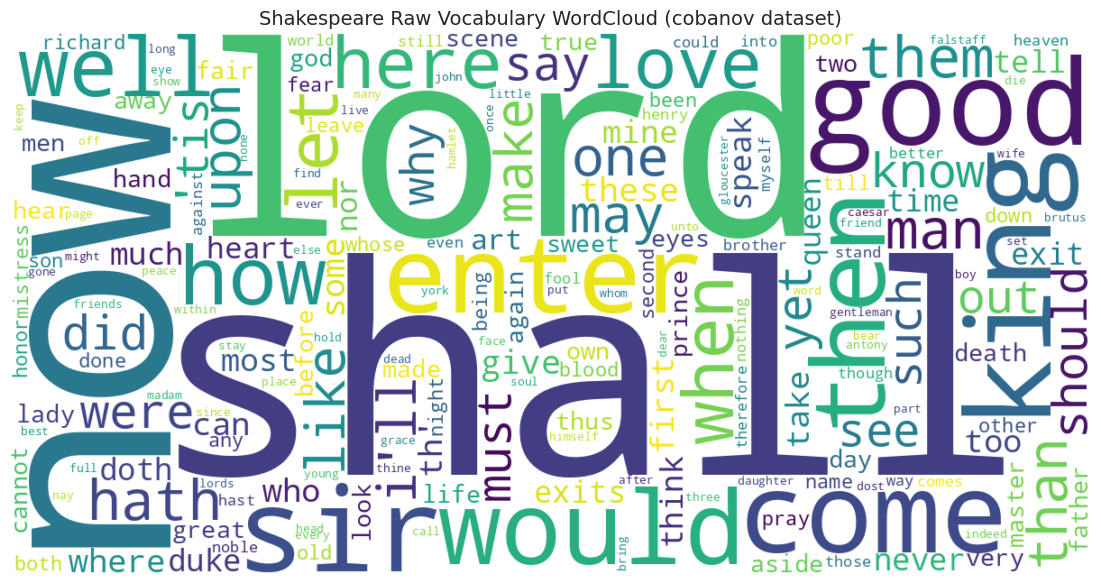

In [3]:
# WordCloud of raw Shakespeare vocabulary
# Filter out common stop words for more interesting cloud
STOP = {'the','and','to','of','a','i','in','that','is','you','it','he',
        'was','for','on','are','with','as','at','be','this','from','or',
        'an','by','not','but','have','had','his','they','we','do','will',
        'my','s','so','if','me','what','there','their','said','thy','thee',
        'thou','your','which','him','her','she','we','our','more','no','all'}

filtered_freq = {w: c for w, c in word_freq.items() if w not in STOP and len(w) > 2}

wc = WordCloud(width=1200, height=600, background_color='white',
               max_words=200, colormap='viridis').generate_from_frequencies(filtered_freq)
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Shakespeare Raw Vocabulary WordCloud (cobanov dataset)', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / 'wordcloud_raw_shakespeare.png', dpi=150)
plt.show()

## 2. Parallel Corpus Statistics

In [4]:
# Load processed train split for analysis
train_records = load_jsonl(PROCESSED_DIR / 'train.jsonl')
test_records  = load_jsonl(PROCESSED_DIR / 'test.jsonl')

# Extract mod→shak pairs only (every other record in bidirectional train)
mod_texts  = []
shak_texts = []
for rec in train_records:
    msgs = rec['messages']
    # mod→shak records have the modern text as 'user' and shak as 'assistant'
    # Check by looking at the system prompt content
    if 'Modern English into Shakespearean' in msgs[0]['content']:
        mod_texts.append(msgs[1]['content'])
        shak_texts.append(msgs[2]['content'])

print(f'Extracted {len(mod_texts):,} mod→shak pairs from train set')

mod_lengths  = [len(t) for t in mod_texts]
shak_lengths = [len(t) for t in shak_texts]

Extracted 20,042 mod→shak pairs from train set


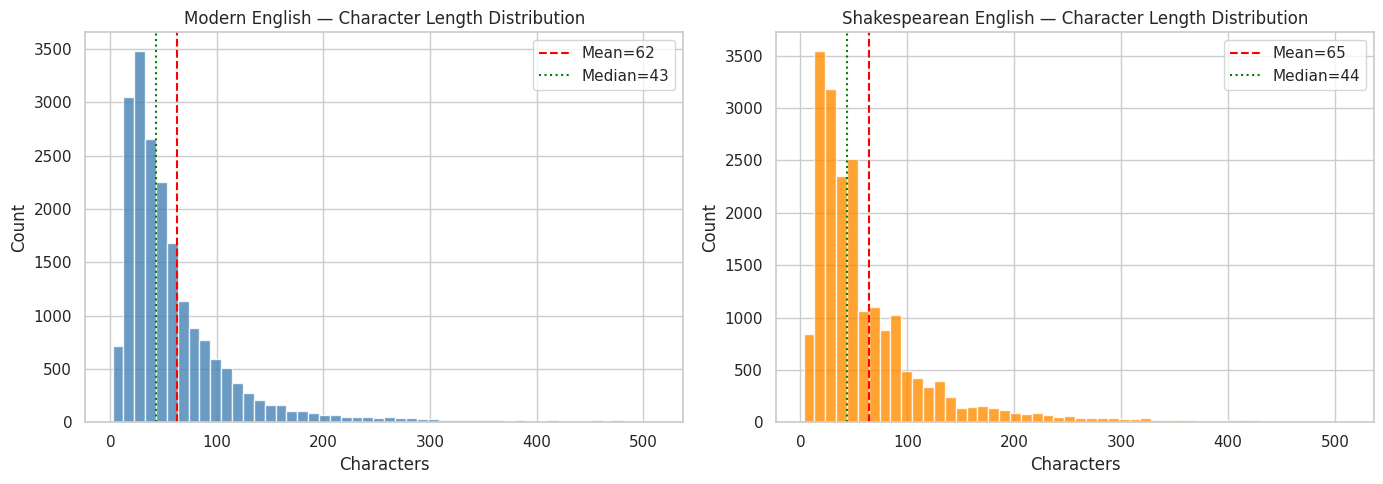

Modern English stats:
count    20042.0
mean        62.3
std         63.2
min          2.0
25%         26.0
50%         43.0
75%         74.0
max        512.0

Shakespearean English stats:
count    20042.0
mean        64.7
std         65.7
min          3.0
25%         25.0
50%         44.0
75%         80.0
max        511.0


In [5]:
# Length distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, lengths, label, color in zip(
    axes,
    [mod_lengths, shak_lengths],
    ['Modern English', 'Shakespearean English'],
    ['steelblue', 'darkorange']
):
    ax.hist(lengths, bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(lengths), color='red', linestyle='--',
               label=f'Mean={np.mean(lengths):.0f}')
    ax.axvline(np.median(lengths), color='green', linestyle=':',
               label=f'Median={np.median(lengths):.0f}')
    ax.set_title(f'{label} — Character Length Distribution')
    ax.set_xlabel('Characters'); ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'length_distributions.png', dpi=150)
plt.show()

print('Modern English stats:')
print(pd.Series(mod_lengths).describe().round(1).to_string())
print('\nShakespearean English stats:')
print(pd.Series(shak_lengths).describe().round(1).to_string())

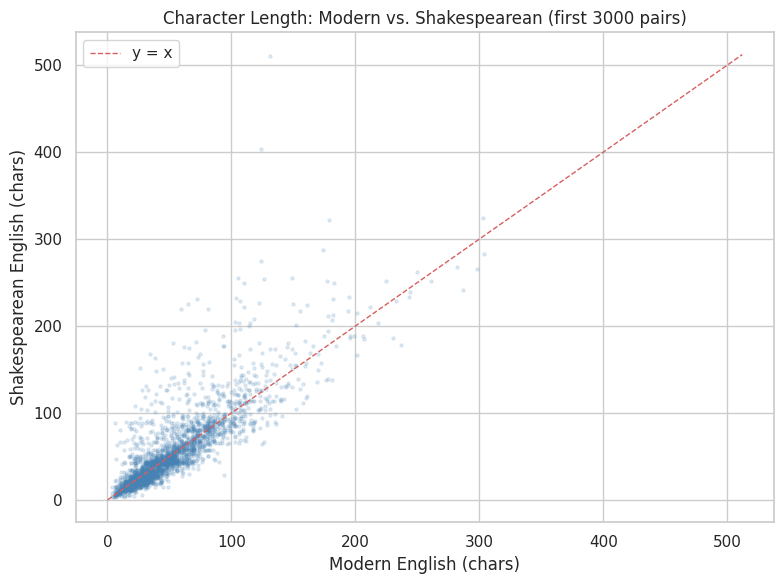

In [6]:
# Length scatter plot (modern vs. Shakespearean)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(mod_lengths[:3000], shak_lengths[:3000], alpha=0.15, s=5, color='steelblue')
lims = [0, max(max(mod_lengths), max(shak_lengths))]
ax.plot(lims, lims, 'r--', linewidth=1, label='y = x')
ax.set_xlabel('Modern English (chars)')
ax.set_ylabel('Shakespearean English (chars)')
ax.set_title('Character Length: Modern vs. Shakespearean (first 3000 pairs)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'length_scatter.png', dpi=150)
plt.show()

In [7]:
# Vocabulary overlap (Jaccard similarity at word level)
def tokenize(text):
    return set(re.findall(r"[a-zA-Z']+", text.lower()))

mod_vocab  = set().union(*[tokenize(t) for t in mod_texts[:5000]])
shak_vocab = set().union(*[tokenize(t) for t in shak_texts[:5000]])

intersection = mod_vocab & shak_vocab
union        = mod_vocab | shak_vocab
jaccard      = len(intersection) / len(union)

print(f'Modern vocab size (first 5k pairs):      {len(mod_vocab):,}')
print(f'Shakespearean vocab size (first 5k):     {len(shak_vocab):,}')
print(f'Vocabulary intersection:                 {len(intersection):,}')
print(f'Vocabulary union:                        {len(union):,}')
print(f'Jaccard similarity:                      {jaccard:.3f} ({jaccard*100:.1f}%)')

# Unique Shakespearean words (archaic vocabulary)
unique_shak = shak_vocab - mod_vocab
shak_word_freq = Counter()
for t in shak_texts:
    shak_word_freq.update(re.findall(r"[a-zA-Z']+", t.lower()))

archaic_top = [(w, shak_word_freq[w]) for w in unique_shak
               if shak_word_freq[w] > 5]
archaic_top.sort(key=lambda x: -x[1])
print(f'\nTop 20 archaic Shakespearean words:')
for word, count in archaic_top[:20]:
    print(f'  {word:<20} {count:>6}')

Modern vocab size (first 5k pairs):      5,231
Shakespearean vocab size (first 5k):     6,100
Vocabulary intersection:                 3,189
Vocabulary union:                        8,142
Jaccard similarity:                      0.392 (39.2%)

Top 20 archaic Shakespearean words:
  thou                   1764
  thee                   1091
  thy                    1046
  hath                    542
  art                     276
  ay                      266
  't                      258
  'tis                    245
  tis                     218
  doth                    210
  nay                     196
  hast                    187
  th                      185
  dost                    163
  hither                  130
  thine                   127
  bid                     120
  hence                   109
  prithee                 105
  ere                     100


## 3. Sample Pair Inspection

In [8]:
import random
random.seed(42)

sample_indices = random.sample(range(len(mod_texts)), 10)

print(f'{"#":<4} {"Modern English":<55} {"Shakespearean English":<55}')
print('-' * 114)
for i in sample_indices:
    m = mod_texts[i][:52] + ('...' if len(mod_texts[i]) > 52 else '')
    s = shak_texts[i][:52] + ('...' if len(shak_texts[i]) > 52 else '')
    print(f'{i:<4} {m:<55} {s:<55}')

#    Modern English                                          Shakespearean English                                  
------------------------------------------------------------------------------------------------------------------
3648 She deserves to have rocks and stones thrown on her ... For charitable prayers Shards , flints and pebbles s...
819  I'll be able to see better from that pine tree over ... Where yond pine does stand I shall discover all .      
9012 Not much .                                              But little .                                           
8024 And should everyone who makes promises and breaks th... And must they all be hanged that swear and lie ?       
7314 Again !                                                 Again !                                                
4572 He will be given safe conduct and money for his pass... His passport shall be made , And crowns for convoy p...
3358 Watch him closely .                                     Give 

In [9]:
# Show 3 full examples in chat-format as they appear in training
import pprint
print('=== Sample chat-format training records ===\n')
for rec in train_records[:3]:
    pprint.pprint(rec)
    print()

=== Sample chat-format training records ===

{'messages': [{'content': 'You are an expert translator of Modern English into '
                          'Shakespearean English. Translate the following '
                          'modern English text into authentic Shakespearean '
                          'style, preserving the meaning while using '
                          'appropriate Early Modern English vocabulary, '
                          'grammar, and poetic diction.',
               'role': 'system'},
              {'content': 'I have half a mind to hit you before you speak '
                          'again .',
               'role': 'user'},
              {'content': "I have a mind to strike thee ere thou speak'st .",
               'role': 'assistant'}]}

{'messages': [{'content': 'You are an expert translator of Shakespearean '
                          'English into Modern English. Translate the '
                          'following Shakespearean text into clear, '
    

## 4. Dataset Summary Statistics

In [10]:
val_records  = load_jsonl(PROCESSED_DIR / 'val.jsonl')

summary = {
    'train_records_total (bidirectional)': len(train_records),
    'train_records_mod2shak': len(mod_texts),
    'val_records': len(val_records),
    'test_records': len(test_records),
    'median_modern_chars': int(np.median(mod_lengths)),
    'median_shakespeare_chars': int(np.median(shak_lengths)),
    'vocab_jaccard_similarity': round(jaccard, 3),
}

print('=== Dataset Summary ===')
for k, v in summary.items():
    print(f'  {k:<50} {v}')

=== Dataset Summary ===
  train_records_total (bidirectional)                40084
  train_records_mod2shak                             20042
  val_records                                        2234
  test_records                                       3515
  median_modern_chars                                43
  median_shakespeare_chars                           44
  vocab_jaccard_similarity                           0.392
